In [6]:
!nvidia-smi

Thu Mar 27 14:11:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:0D:00.0 Off |                    0 |
| N/A   43C    P0             82W /  350W |   34587MiB /  46068MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [8]:
import torch
torch.cuda.empty_cache()

In [9]:
!nvidia-smi

Thu Mar 27 14:18:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:0D:00.0 Off |                    0 |
| N/A   44C    P0            115W /  350W |   11387MiB /  46068MiB |    100%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [1]:
import requests
from PIL import Image
import pandas as pd
import io
import torch
import numpy as np
from transformers import AutoProcessor, LlavaForConditionalGeneration

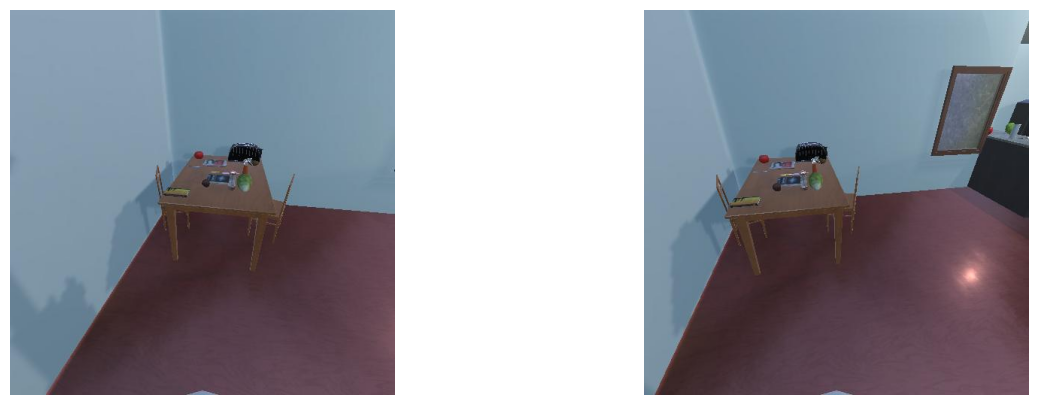

The first image is from the beginning of the video and the second image is from the end. How did the camera likely move when shooting the video?
['rotated right' 'rotated left']
rotated right


In [2]:
df = pd.read_parquet('/projectnb/cs598/projects/cool_proj/dataset', engine='pyarrow')#change path here

example = df.iloc[10]
images = [Image.open(io.BytesIO(im_bytes)) for im_bytes in example['image_bytes']]

import matplotlib.pyplot as plt

# Display images
fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

if len(images) == 1:
    axes.imshow(images[0])
    axes.axis("off")
else:
    for ax, img in zip(axes, images):
        ax.imshow(img)
        ax.axis("off")

plt.show()
question = example['question']
print(question)
answer_choices = example['answers']
print(answer_choices)
correct_answer = example['correct_answer']
print(correct_answer)

# Function to convert bytes to BytesIO objects
def convert_to_bytesio(image_bytes):
    return np.asarray([Image.open(io.BytesIO(im_bytes)) for im_bytes in image_bytes], dtype=np.uint8)
    
# Apply the conversion to the entire column
df['image_bytes'] = df['image_bytes'].apply(convert_to_bytesio)


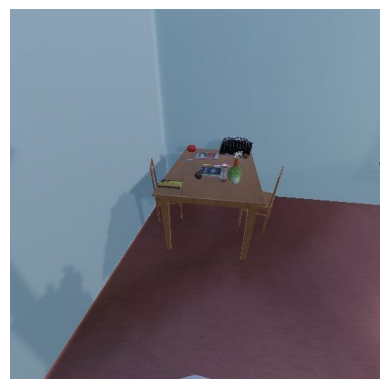

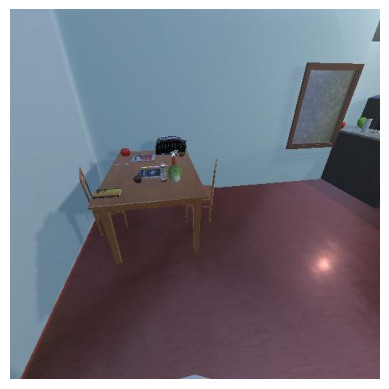

In [4]:
example = df.iloc[10]
# images = [Image.open(io.BytesIO(im_bytes)) for im_bytes in example['image_bytes']]
for i in range(example['image_bytes'].shape[0]):
    plt.imshow(example['image_bytes'][i])  # Matplotlib expects RGB format
    plt.axis('off')  # Hide axes
    plt.show()

In [3]:
model_id = "llava-hf/llava-1.5-7b-hf"
cache_dir = 'SuryaWorking/LLaVa' #change dir
torch.cuda.empty_cache()
model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    cache_dir = cache_dir,
    torch_dtype=torch.float16, 
    low_cpu_mem_usage=True, 
).to(0)

processor = AutoProcessor.from_pretrained(model_id, cache_dir = cache_dir)



Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [9]:
torch.cuda.empty_cache()
from tqdm import tqdm
import re
def extract_final_answer(text):
# Split at "ASSISTANT:" to isolate the assistant's response
    match = re.search(r"Final Answer:\s*(.*)", text)
    if match:
        result = match.group(1)
        return result.lower()
        
def predict_all(dataset, device='cuda'):
    predictions = []
    n_correct = 0
    for i in (pbar := tqdm(range(len(dataset['question'])))):
        input_image = dataset['image_bytes'][i]
        question = dataset['question'][i]
        answer_choices = dataset['answers'][i]
            


        input_prompt = f'''
                                Answer the below question using the image and given options
        
                                Question: {question}
        
                            
                                Analyze the image and give a step by step reasoning to the user for your answer.
        
                                ONLY Choose one of the options below that matches your reasoning.
                                Options: {answer_choices}                        
                                Format your response as follows else you fail:
                                    Reasoning: <step-by-step explanation>
                                    
                                    Final Answer: [your selected option] 
                                    Your final answer should be as above, else you'll be considered wrong.
                               '''

        content = [{"type": "text", "text": f"{input_prompt}"}]
        for j in range(len(input_image)):
            content.append({"type": "image", f"image {j+1}" : f"{input_image[j]}"})
            # print(content)
        conversation = [
                {
            
                  "role": "user",
                  "content": content,
                },
            ]
        prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
        inputs = processor(images=input_image, text=prompt, return_tensors='pt').to(0, torch.float16)
        output = model.generate(**inputs, max_new_tokens=200, do_sample=False)
        prediction_text = processor.decode(output[0], skip_special_tokens=True)
        prediction_text = prediction_text.replace(input_prompt, "")
        
        answer = extract_final_answer(prediction_text)
        print(answer)
        print('--')
        print(prediction_text)
        print('--')
        print(dataset['correct_answer'][i])
        # print(prediction_text)
        # print("Q: ",question)
        # print("options: ",answer_choices)
        # print("answer: ",prediction)
        # print("Correct_a: ",dataset['correct_answer'][i])
        predictions.append({
            "question": question,
            "answers": answer_choices,
            "pred_text": prediction_text,
            "prediction": answer,
            "correct_answer": dataset['correct_answer'][i]
        })
        
        try:
            if len(answer) > 0:
                if answer[0] in dataset['correct_answer'][i] or dataset['correct_answer'][i] in answer[0]:
                    print('yay?')
                    n_correct += 1
                else:
                    pass
                
        except:
            pass
            
        pbar.set_description(f'{n_correct} correct')
    
    return predictions

predictions = predict_all(df) #2187, 16:36

0 correct:   0%|          | 1/4001 [00:00<10:37,  6.27it/s]

None
--
USER:  
 
 ASSISTANT: No
--
Chair was moved left and towards the camera in the first frame


0 correct:   0%|          | 2/4001 [00:00<22:12,  3.00it/s]

None
--
USER:  
 
 ASSISTANT: Reasoning: The camera likely moved by rotating left.
--
did not move


1 correct:   0%|          | 5/4001 [00:01<22:02,  3.02it/s]

...

further
--
USER:  
 ASSISTANT: Reasoning: The bottle is already close to the marked point. If you move to the 'X' marked point and turned left by 90 degrees, the bottle will be further away.

Final Answer: Further
--
Closer


828 correct: 100%|█████████▉| 4000/4001 [42:55<00:01,  1.31s/it]

further
--
USER:  
 ASSISTANT: Reasoning: If you move to the 'X' marked point in the image and turned left by 90 degrees, the black chair with circular backrest (near marked 2) will get further away.

Final Answer: Further
--
Closer


828 correct: 100%|██████████| 4001/4001 [42:56<00:00,  1.55it/s]

further
--
USER:  
 ASSISTANT: Reasoning: The table is already close to the marked 10. If you move to the 'X' marked point and turned left by 90 degrees, the table will be further away.

Final Answer: Further
--
Closer


In [7]:
import json
for entry in predictions:
    for key, value in entry.items():
        if isinstance(value, np.ndarray):
            entry[key] = value.tolist()  # Convert ndarray to list

# Save to file
with open("Llava_Base.txt", "w", encoding="utf-8") as f:
    json.dump(predictions, f, indent=4, ensure_ascii=False)

print("Predictions saved to LLava_Base.txt")

Predictions saved to LLava_Base.txt
